In [96]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("data/sample.tif", cv2.IMREAD_GRAYSCALE)
print(img.shape, img.dtype)
print(img.min(), img.max())

(768, 1024) uint8
0 255


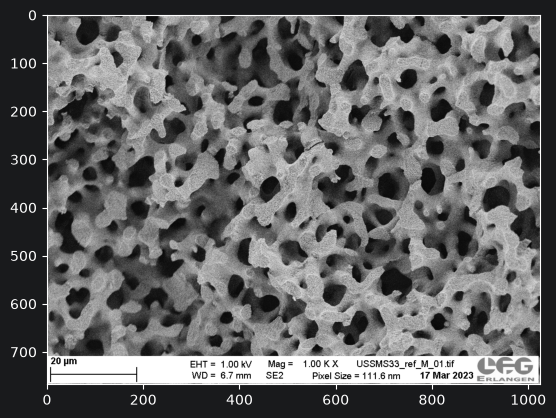

In [97]:
plt.imshow(img, cmap="gray")
plt.show()

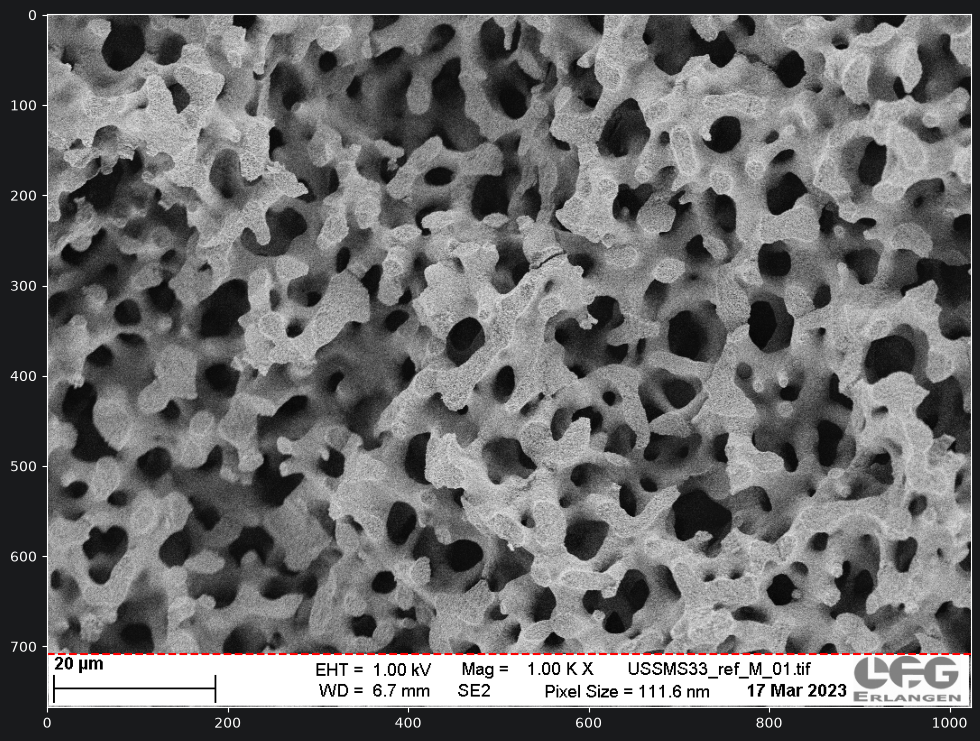

In [98]:
plt.figure(figsize=(12, 9))
plt.imshow(img, cmap="gray")
plt.axhline(y=708, color="red", linestyle="--")
plt.show()

(708, 1024)


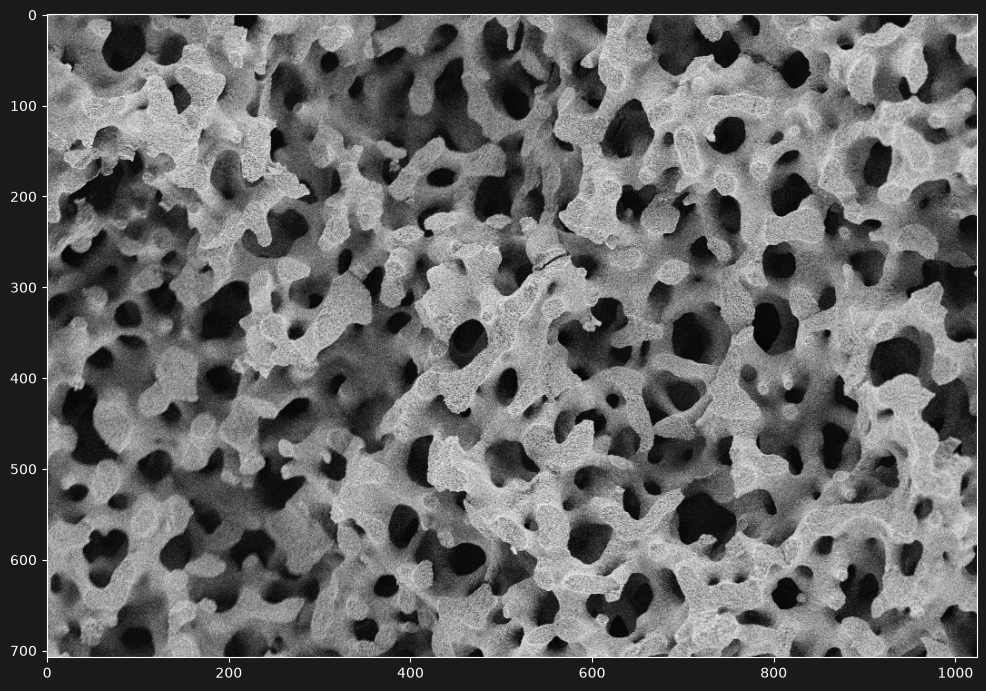

In [99]:
img_cropped = img[0:708, :]
print(img_cropped.shape)

plt.figure(figsize=(12, 9))
plt.imshow(img_cropped, cmap="gray")
plt.show()

Построим гистограмму для этого обрезанного изображения, чтобы понять насколько четко разделяются по яркости поры и материал

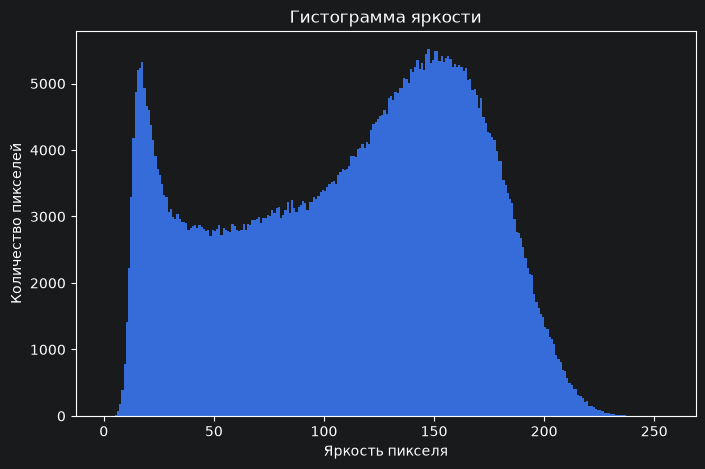

In [100]:
plt.figure(figsize=(8, 5))
plt.hist(img_cropped.ravel(), bins=256, range=(0, 256))
plt.xlabel('Яркость пикселя')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма яркости')
plt.show()

Видим четко бимодальное распределение, можно применить метод Otsu, чтобы определить порог для бинарного разделения пора / не пора

Посчитанный порог методом Otsu: 102.0


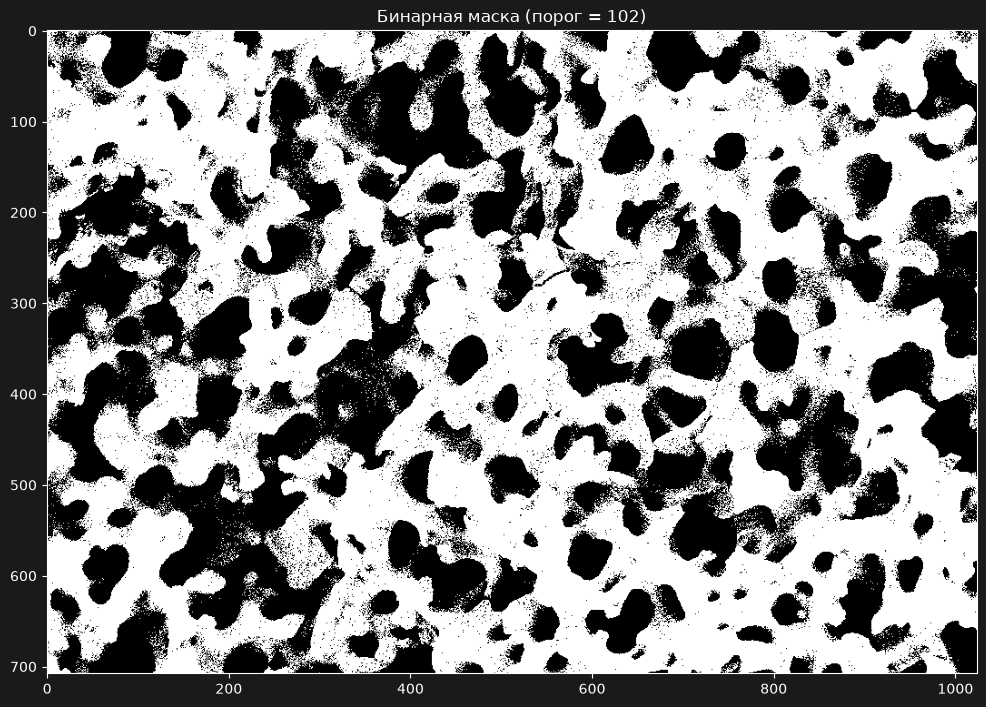

In [101]:
threshold_value, binary_mask = cv2.threshold(img_cropped, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'Посчитанный порог методом Otsu: {threshold_value}')
plt.figure(figsize=(12, 9))
plt.imshow(binary_mask, cmap="gray")
plt.title(f'Бинарная маска (порог = {threshold_value:.0f})')
plt.show()

Необходимо почистить от морфологического шума (точки/крапинки)

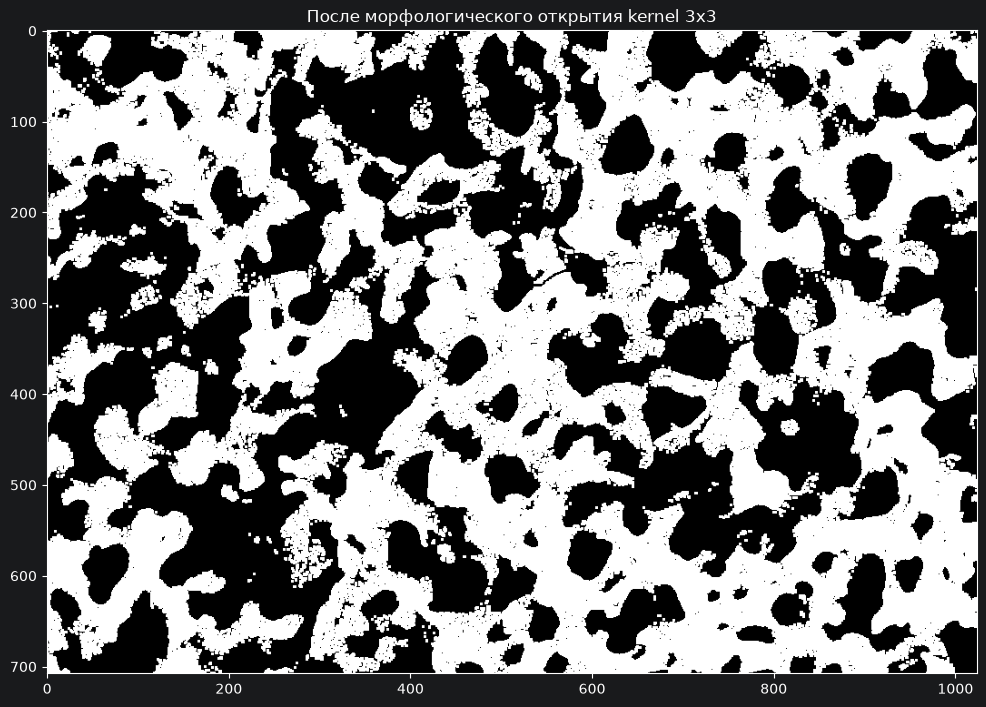

In [102]:
kernel = np.ones((3, 3), np.uint8)

mask_opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(12, 9))
plt.imshow(mask_opened, cmap="gray")
plt.title('После морфологического открытия kernel 3х3')
plt.show()

Попробуем размер kernel сделать 5 x 5


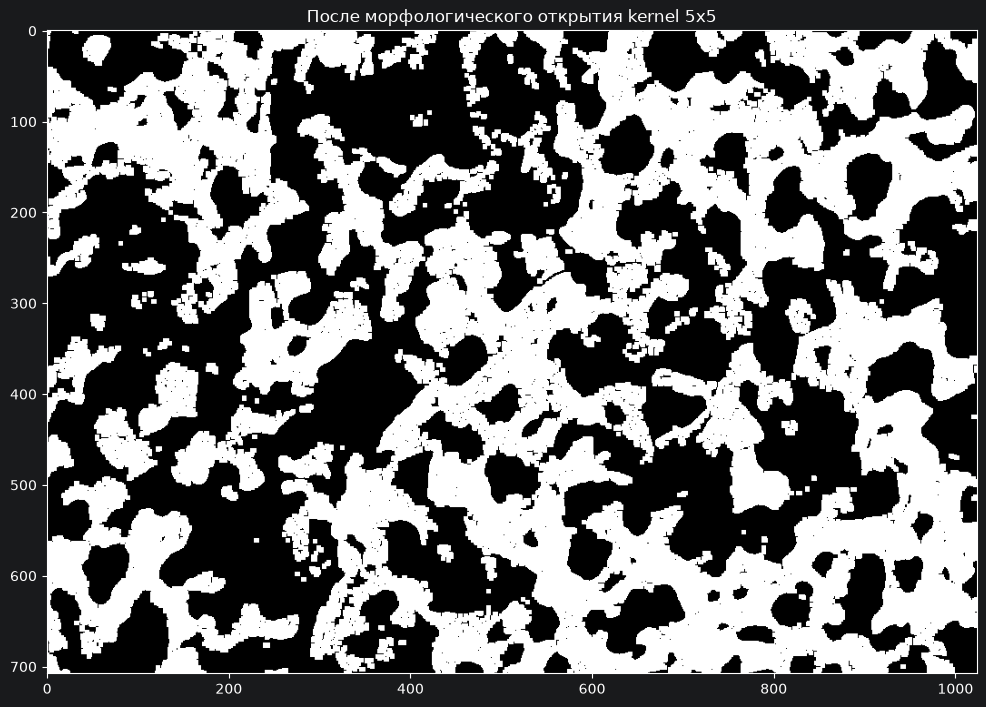

In [103]:
kernel = np.ones((5, 5), np.uint8)

mask_opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(12, 9))
plt.imshow(mask_opened, cmap="gray")
plt.title('После морфологического открытия kernel 5x5')
plt.show()

Возможно стоит попробовать убрать шум на исходном изображении (до применения Otsu), а не очищать от шума бинарную маску

Попробуем применить медианную фильтрацию (сглаживание) к исходному изображению

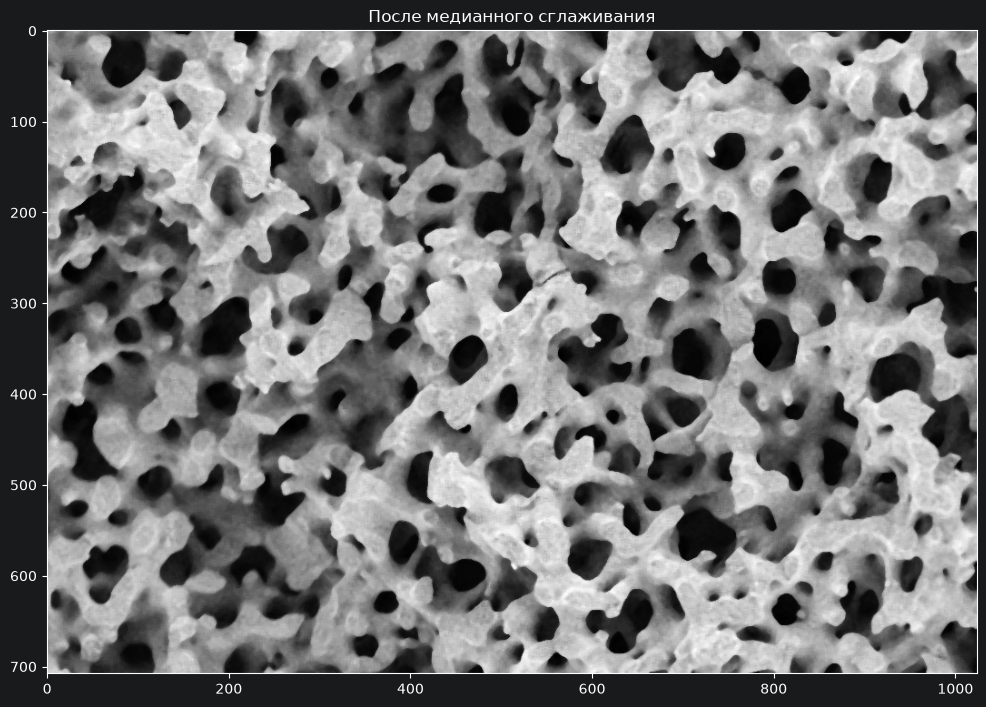

In [104]:
img_smoothed = cv2.medianBlur(img_cropped, 5)

plt.figure(figsize=(12, 9))
plt.imshow(img_smoothed, cmap="gray")
plt.title('После медианного сглаживания')
plt.show()

Теперь к нему применем Otsu

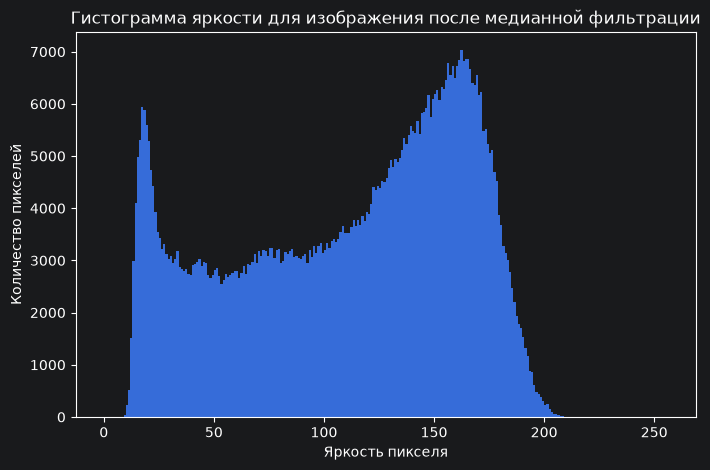

In [105]:
plt.figure(figsize=(8, 5))
plt.hist(img_smoothed.ravel(), bins=256, range=(0, 256))
plt.xlabel('Яркость пикселя')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма яркости для изображения после медианной фильтрации')
plt.show()

После сглаживания (медианная фильтрация) Otsu-threshold составляет: 100.0


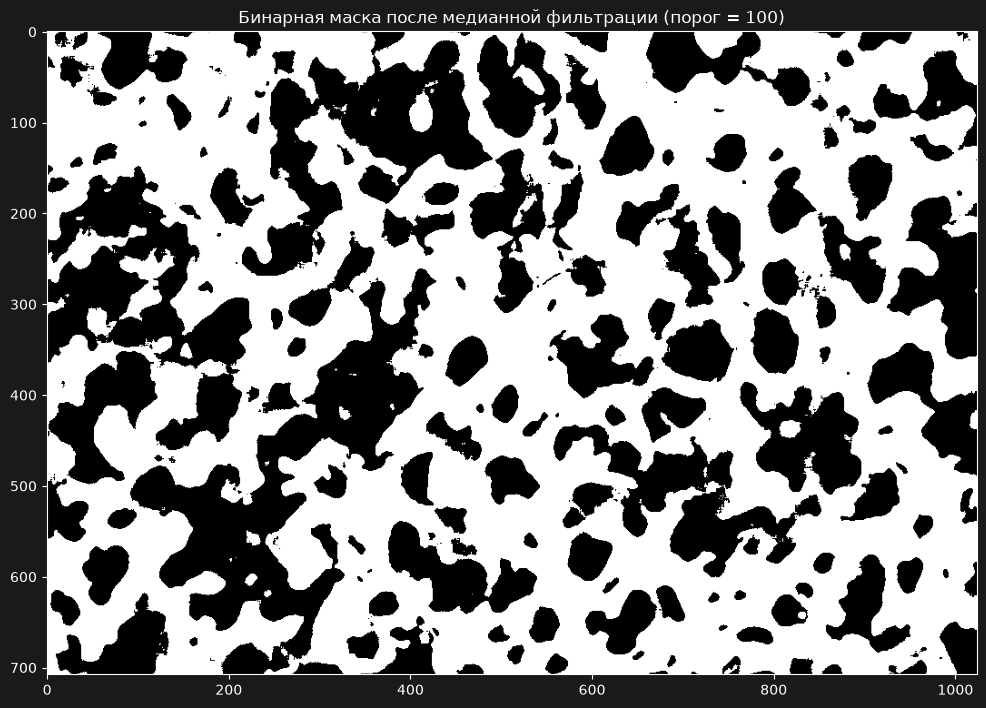

In [106]:
threshold_value2, binary_mask2 = cv2.threshold(img_smoothed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'После сглаживания (медианная фильтрация) Otsu-threshold составляет: {threshold_value2}')

plt.figure(figsize=(12, 9))
plt.imshow(binary_mask2, cmap="gray")
plt.title(f'Бинарная маска после медианной фильтрации (порог = {threshold_value2:.0f})')
plt.show()

Придерживаемся такого пайплайна:
1. Загрузка
2. Обрезка панели
3. Медианное сглаживание
4. Гистограмма/Otsu порог → чистая бинарная маска
5. Поиск контуров (отдельных пор) на этой маске
6. Измерение размеров каждой поры
7. Калибровка пикселей в реальные единицы (nm)
8. Статистика/классификация

Глядя на бинарную маску, видно, что несколько отдельных пор слились в одно большое черное пятно (там где перемычка была тонкой и утонула в шуме/тенях). Сначала доработаем по пайплайну как есть и получим результат, который сравним с результатом применения "Watershed".

Ищем контуры пор на поулеченной маске

Найдено контуров: 274


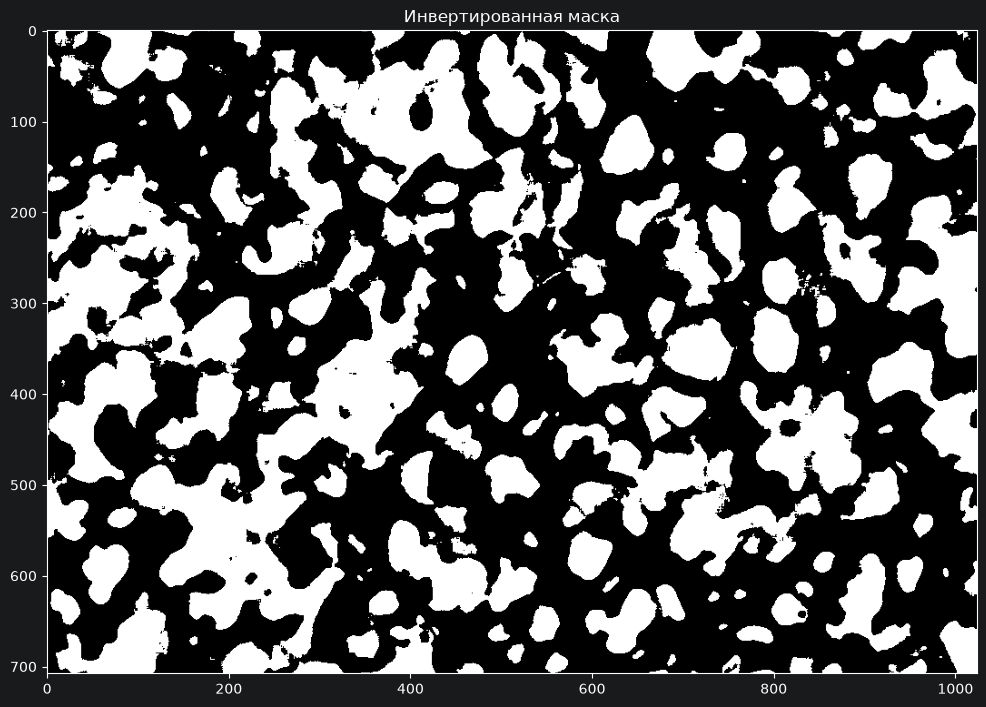

In [113]:
inverted_mask = cv2.bitwise_not(binary_mask2)   #побитово делаем инверсию (черное в белое, белое в черное)

contours, hierarchy = cv2.findContours(inverted_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'Найдено контуров: {len(contours)}')

plt.figure(figsize=(12, 9))
plt.imshow(inverted_mask, cmap="gray")
plt.title('Инвертированная маска')
plt.show()